In [ ]:
!pip install timm segmentation-models-pytorch albumentations roboflow 

In [ ]:
!pip install segmentation-models-pytorch timm

In [3]:
import os
import cv2
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from kaggle_secrets import UserSecretsClient
from roboflow import Roboflow

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
import multiprocessing

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import train_test_split

## Dataset + EDA

In [4]:
rf = Roboflow(api_key=UserSecretsClient().get_secret('ROBOFLOW_API_KEY'))
project = rf.workspace("chetan-sharma-n4cau").project("room-sepration-woywo")
version = project.version(2)
dataset = version.download("png-mask-semantic")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Room-sepration--2 in png-mask-semantic:: 100%|██████████| 1255/1255 [00:00<00:00, 12765.56it/s]


In [5]:
!ls /kaggle/working/Room-sepration--2/

README.dataset.txt  README.roboflow.txt  test  train  valid


In [6]:
def sorting_data(source_dir):
    BASE_DIR = source_dir

    IMG_DIR = os.path.join(BASE_DIR, "images")
    MASK_DIR = os.path.join(BASE_DIR, "masks")

    os.makedirs(IMG_DIR, exist_ok=True)
    os.makedirs(MASK_DIR, exist_ok=True)

    for file in os.listdir(BASE_DIR):
        if file.endswith(".jpg") or file.endswith(".png"):
            
            if "_mask" in file:
                shutil.move(os.path.join(BASE_DIR, file), os.path.join(MASK_DIR, file))
            else:
                shutil.move(os.path.join(BASE_DIR, file), os.path.join(IMG_DIR, file))
    
    print("Done restructuring!", source_dir)

In [7]:
data_dir = '/kaggle/working/Room-sepration--2'

train_dir= os.path.join(data_dir,'train')
test_dir = os.path.join(data_dir,'test')
val_dir= os.path.join(data_dir,'valid')

In [8]:
for path in [train_dir, test_dir, val_dir]:
    sorting_data(path)

Done restructuring! /kaggle/working/Room-sepration--2/train
Done restructuring! /kaggle/working/Room-sepration--2/test
Done restructuring! /kaggle/working/Room-sepration--2/valid


In [9]:
img_dir = os.path.join(train_dir, 'images')
mask_dir = os.path.join(train_dir, 'masks')

images = sorted(os.listdir(img_dir))
masks = sorted(os.listdir(mask_dir))

print(images[:5])
print(masks[:5])

['-1_jpg.rf.7af20ff9b2ecb03f6aca6fa538902c65.jpg', '-_jpeg_jpg.rf.8b5b7c20c3c02fc3128079db951e25d5.jpg', '-_jpeg_jpg.rf.f2c43d3b6f0350ffae74ec458453430f.jpg', '01_677-1200x800_jpg.rf.f6e0cb559944266ecbd514f785a79c97.jpg', '03facfd7b9580f3d02c5308f1b9c5eb0_jpg.rf.0c272580169db1ab26f7782a4a18daa3.jpg']
['-1_jpg.rf.7af20ff9b2ecb03f6aca6fa538902c65_mask.png', '-_jpeg_jpg.rf.8b5b7c20c3c02fc3128079db951e25d5_mask.png', '-_jpeg_jpg.rf.f2c43d3b6f0350ffae74ec458453430f_mask.png', '01_677-1200x800_jpg.rf.f6e0cb559944266ecbd514f785a79c97_mask.png', '03facfd7b9580f3d02c5308f1b9c5eb0_jpg.rf.0c272580169db1ab26f7782a4a18daa3_mask.png']


## Preparing Dataset

In [10]:
TRAIN_IMG_DIR = train_dir + "/images"
TRAIN_MASK_DIR = train_dir + "/masks"

VAL_IMG_DIR = val_dir + "/images"
VAL_MASK_DIR = val_dir + "/masks"

TEST_IMG_DIR = test_dir + "/images"
TEST_MASK_DIR = test_dir + "/masks"


train_transform = A.Compose([ A.Resize(256, 256), A.Normalize(), ToTensorV2()])

val_transform = A.Compose([A.Resize(256, 256), A.Normalize(), ToTensorV2()])


In [11]:
class SegDataset(Dataset):
    def __init__(self, img_dir, mask_dir, transform=None):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.images = sorted(os.listdir(img_dir))
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]

        base_name = os.path.splitext(img_name)[0]
        mask_name = base_name + "_mask.png"

        img_path = os.path.join(self.img_dir, img_name)
        mask_path = os.path.join(self.mask_dir, mask_name)

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_path, 0)
        assert mask is not None, f"Missing mask for {img_name}"

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        return image, mask.long()

In [12]:
train_dataset = SegDataset(TRAIN_IMG_DIR, TRAIN_MASK_DIR, train_transform)
val_dataset   = SegDataset(VAL_IMG_DIR, VAL_MASK_DIR, val_transform)
test_dataset  = SegDataset(TEST_IMG_DIR, TEST_MASK_DIR, val_transform)

train_loader = DataLoader(train_dataset,batch_size=8,shuffle=True,num_workers=2,pin_memory=True)

val_loader = DataLoader( val_dataset,batch_size=8,shuffle=False,num_workers=2,pin_memory=True )

test_loader = DataLoader( test_dataset, batch_size=8, shuffle=False, num_workers=2,pin_memory=True)

In [13]:
mask = cv2.imread(os.path.join(mask_dir, masks[0]), 0)
print(np.unique(mask))

[ 0  6 10 12 23 26 27 28 30 31 32 33 34 35 36]


Text(0.5, 1.0, 'Mask')

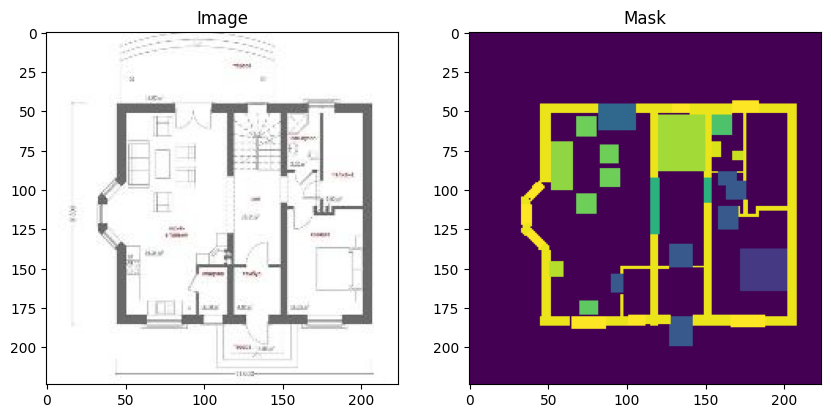

In [14]:
img = cv2.imread(os.path.join(img_dir, images[0]))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

mask = cv2.imread(os.path.join(mask_dir, masks[0]), 0)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Image")

plt.subplot(1,2,2)
plt.imshow(mask)
plt.title("Mask")

## Loading Unet + Efficientnet-b0 Segmentation Model

In [43]:
import segmentation_models_pytorch as smp

model = smp.Unet(
    encoder_name="efficientnet-b0",
    encoder_weights="imagenet",
    classes=38,
    activation=None
)

### freeze encoder

In [44]:
for param in model.encoder.parameters():
    param.requires_grad = False

### loss functions and optimizers

In [45]:
ce_loss = nn.CrossEntropyLoss()

def dice_loss(pred, target, smooth=1e-5):
    pred = torch.softmax(pred, dim=1)
    target_one_hot = F.one_hot(target, num_classes=38).permute(0,3,1,2)

    intersection = (pred * target_one_hot).sum(dim=(2,3))
    union = pred.sum(dim=(2,3)) + target_one_hot.sum(dim=(2,3))

    dice = (2 * intersection + smooth) / (union + smooth)
    return 1 - dice.mean()

def loss_fn(pred, target):
    return ce_loss(pred, target) + dice_loss(pred, target)

In [46]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)

## Training phase 1

In [47]:
EPOCHS = 30

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{EPOCHS}]", leave=False)

    for imgs, masks in loop:
        imgs, masks = imgs.to(device), masks.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)

        loss = loss_fn(outputs, masks)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        loop.set_postfix({
            "loss": f"{loss.item():.4f}",
            "avg_loss": f"{total_loss / (loop.n + 1):.4f}",
            "lr": optimizer.param_groups[0]["lr"]
        })

    avg_train_loss = total_loss / len(train_loader)

    model.eval()
    miou_scores = []

    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = model(imgs)

            miou = compute_miou(outputs, masks)
            miou_scores.append(miou)

    avg_miou = np.mean(miou_scores)

    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {avg_train_loss:.4f}")
    print(f"Val mIoU: {avg_miou:.4f}")


Epoch 1/30
Train Loss: 4.3680
Val mIoU: 0.0181



Epoch 2/30
Train Loss: 3.6222
Val mIoU: 0.0385



Epoch 3/30
Train Loss: 2.9393
Val mIoU: 0.0700



Epoch 4/30
Train Loss: 2.3851
Val mIoU: 0.0834



Epoch 5/30
Train Loss: 2.0257
Val mIoU: 0.0844


...


Epoch 26/30
Train Loss: 1.2285
Val mIoU: 0.1542



Epoch 27/30
Train Loss: 1.2187
Val mIoU: 0.1553



Epoch 28/30
Train Loss: 1.2047
Val mIoU: 0.1545



Epoch 29/30
Train Loss: 1.1970
Val mIoU: 0.1553



Epoch 30/30
Train Loss: 1.1948
Val mIoU: 0.1564


### validation 

In [48]:
def compute_miou(pred, target, num_classes=38):
    pred = torch.argmax(pred, dim=1)
    ious = []

    for cls in range(num_classes):
        pred_inds = (pred == cls)
        target_inds = (target == cls)

        intersection = (pred_inds & target_inds).sum().item()
        union = (pred_inds | target_inds).sum().item()

        if union == 0:
            continue

        ious.append(intersection / union)

    return np.mean(ious)

In [49]:
model.eval()
miou_scores = []

with torch.no_grad():
    for imgs, masks in val_loader:
        imgs, masks = imgs.to(device), masks.to(device)

        outputs = model(imgs)
        miou = compute_miou(outputs, masks)

        miou_scores.append(miou)

print("Validation mIoU:", np.mean(miou_scores))

Validation mIoU: 0.1563939543003798


## Visualization

In [50]:
import matplotlib.pyplot as plt

def visualize_predictions(model, loader, device, num_samples=3):
    model.eval()
    
    imgs, masks = next(iter(loader))
    imgs, masks = imgs.to(device), masks.to(device)

    with torch.no_grad():
        outputs = model(imgs)
        preds = torch.argmax(outputs, dim=1)

    imgs = imgs.cpu()
    masks = masks.cpu()
    preds = preds.cpu()

    for i in range(num_samples):
        plt.figure(figsize=(12,4))

        # Image
        plt.subplot(1,3,1)
        plt.imshow(imgs[i].permute(1,2,0))
        plt.title("Image")
        plt.axis("off")

        # Ground Truth
        plt.subplot(1,3,2)
        plt.imshow(masks[i])
        plt.title("Ground Truth")
        plt.axis("off")

        # Prediction
        plt.subplot(1,3,3)
        plt.imshow(preds[i])
        plt.title("Prediction")
        plt.axis("off")

        plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.018207..2.6399999].


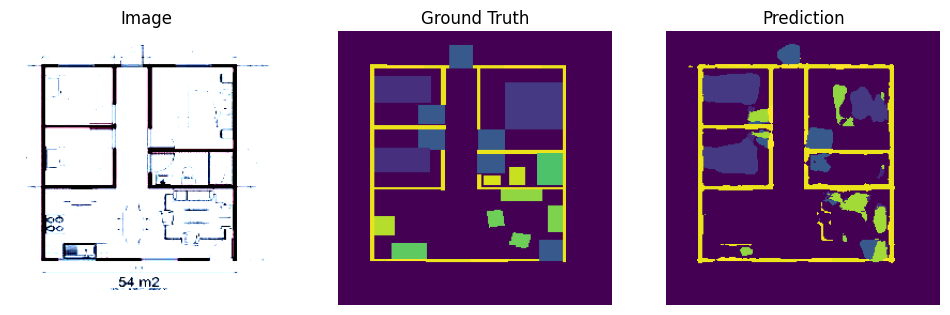

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6399999].


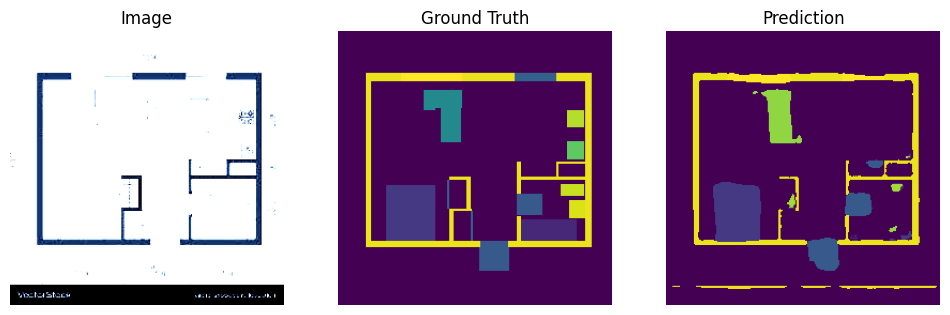

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6399999].


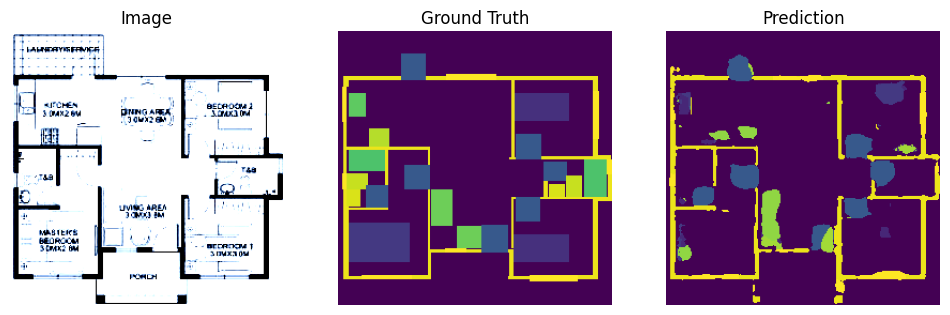

In [51]:
visualize_predictions(model, val_loader, device)

In [52]:
def overlay_mask(image, mask, alpha=0.5):
    image = image.permute(1,2,0).numpy()
    mask = mask.numpy()

    colored_mask = plt.cm.jet(mask / mask.max())[:, :, :3] 
    overlay = (1 - alpha) * image + alpha * colored_mask

    return overlay

def visualize_overlay(model, loader, device, num_samples=3):
    model.eval()

    imgs, masks = next(iter(loader))
    imgs, masks = imgs.to(device), masks.to(device)

    with torch.no_grad():
        outputs = model(imgs)
        preds = torch.argmax(outputs, dim=1)

    imgs = imgs.cpu()
    preds = preds.cpu()

    for i in range(num_samples):
        plt.figure(figsize=(10,4))

        # Original
        plt.subplot(1,2,1)
        plt.imshow(imgs[i]
                   .permute(1,2,0))
        plt.title("Original")

        # Overlay
        overlay = overlay_mask(imgs[i], preds[i])
        plt.subplot(1,2,2)
        plt.imshow(overlay)
        plt.title("Prediction Overlay")

        plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.018207..2.6399999].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.009103536605835..1.8199999332427979].


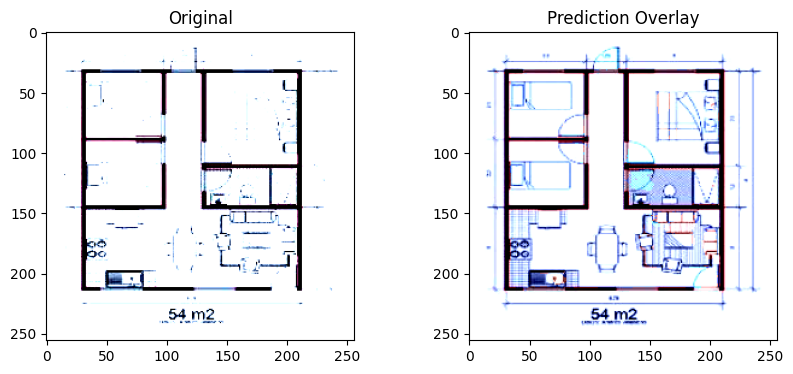

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6399999].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0589519739151..1.8199999332427979].


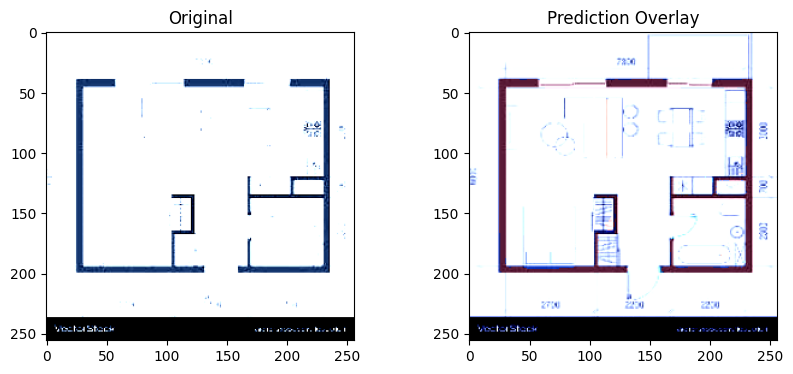

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6399999].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0503896474838257..1.8199999332427979].


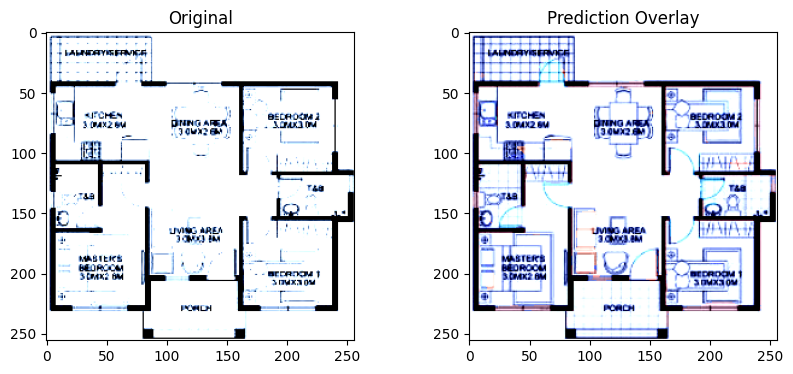

In [53]:
visualize_overlay(model, val_loader, device)

### testing

In [55]:
def dice_score(pred, target, num_classes=38):
    pred = torch.argmax(pred, dim=1)
    dice_scores = []

    for cls in range(num_classes):
        pred_inds = (pred == cls)
        target_inds = (target == cls)

        intersection = (pred_inds & target_inds).sum().item()
        total = pred_inds.sum().item() + target_inds.sum().item()

        if total == 0:
            continue

        dice = (2 * intersection) / total
        dice_scores.append(dice)

    return np.mean(dice_scores)

In [56]:
model.eval()

test_miou = []
pixel_accs = []
dice_scores = []

with torch.no_grad():
    for imgs, masks in test_loader:
        imgs, masks = imgs.to(device), masks.to(device)

        outputs = model(imgs)
        preds = torch.argmax(outputs, dim=1)

        # mIoU
        miou = compute_miou(outputs, masks)
        test_miou.append(miou)

        # Pixel Accuracy
        correct = (preds == masks).sum().item()
        total = torch.numel(preds)
        pixel_accs.append(correct / total)

        # Dice
        dice = dice_score(outputs, masks)
        dice_scores.append(dice)

# Final results
print("Test mIoU:", np.mean(test_miou))
print("Pixel Accuracy:", np.mean(pixel_accs))
print("Test Dice Score:", np.mean(dice_scores))

Test mIoU: 0.15317667394614448
Pixel Accuracy: 0.867435073852539
Test Dice Score: 0.2007585735903802


#### per class iou

In [57]:
def per_class_iou(pred, target, num_classes=38):
    pred = torch.argmax(pred, dim=1)
    ious = []

    for cls in range(num_classes):
        pred_inds = (pred == cls)
        target_inds = (target == cls)

        intersection = (pred_inds & target_inds).sum().item()
        union = (pred_inds | target_inds).sum().item()

        if union == 0:
            ious.append(float('nan'))
        else:
            ious.append(intersection / union)

    return ious

In [58]:
class_ious = []

with torch.no_grad():
    for imgs, masks in test_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        outputs = model(imgs)

        ious = per_class_iou(outputs, masks)
        class_ious.append(ious)

class_ious = np.nanmean(class_ious, axis=0)

for i, iou in enumerate(class_ious):
    print(f"Class {i}: IoU = {iou:.4f}")

Class 0: IoU = 0.8761
Class 1: IoU = nan
Class 2: IoU = nan
Class 3: IoU = nan
Class 4: IoU = 0.0631
Class 5: IoU = 0.0000
Class 6: IoU = 0.4261
Class 7: IoU = nan
Class 8: IoU = nan
Class 9: IoU = nan
Class 10: IoU = 0.5055
Class 11: IoU = 0.0000
Class 12: IoU = 0.0000
Class 13: IoU = nan
Class 14: IoU = 0.0000
Class 15: IoU = nan
Class 16: IoU = nan
Class 17: IoU = 0.0004
Class 18: IoU = nan
Class 19: IoU = nan
Class 20: IoU = nan
Class 21: IoU = nan
Class 22: IoU = nan
Class 23: IoU = 0.0000
Class 24: IoU = nan
Class 25: IoU = nan
Class 26: IoU = 0.0000
Class 27: IoU = 0.0000
Class 28: IoU = 0.0000
Class 29: IoU = 0.0002
Class 30: IoU = 0.2000
Class 31: IoU = 0.1800
Class 32: IoU = 0.0000
Class 33: IoU = 0.0000
Class 34: IoU = 0.0000
Class 35: IoU = 0.5237
Class 36: IoU = 0.3423
Class 37: IoU = nan


Mean of empty slice


### save best model

In [59]:
torch.save(model.state_dict(), "unet_efficientnetb0_segmentation.pth")

## Inference using saved model

In [60]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = smp.Unet(
    encoder_name="efficientnet-b0",
    encoder_weights=None,   # IMPORTANT
    classes=38,
    activation=None
)

model.load_state_dict(torch.load("unet_efficientnetb0_segmentation.pth", map_location=device))
model.to(device)
model.eval()

Unet(
  (encoder): EfficientNetEncoder(
    (_conv_stem): Conv2dStaticSamePadding(
      3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False
      (static_padding): ZeroPad2d((0, 1, 0, 1))
    )
    (_bn0): BatchNorm2d(32, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
    (_blocks): ModuleList(
      (0): MBConvBlock(
        (_expand_conv): Identity()
        (_bn0): Identity()
        (_depthwise_conv): Conv2dStaticSamePadding(
          32, 32, kernel_size=(3, 3), stride=[1, 1], groups=32, bias=False
          (static_padding): ZeroPad2d((1, 1, 1, 1))
        )
        (_bn1): BatchNorm2d(32, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
        (_se_reduce): Conv2dStaticSamePadding(
          32, 8, kernel_size=(1, 1), stride=(1, 1)
          (static_padding): Identity()
        )
        (_se_expand): Conv2dStaticSamePadding(
          8, 32, kernel_size=(1, 1), stride=(1, 1)
          (static_padding): Identit

### transform

In [62]:
transform = A.Compose([
    A.Resize(256, 256),
    A.Normalize(),
    ToTensorV2()
])

In [63]:
img_path = "/kaggle/input/datasets/cschetansharma/test-for-efficientvit/1-bedroom-house-plan.jpg"

image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

### preprocess

In [64]:
augmented = transform(image=image)
input_tensor = augmented["image"].unsqueeze(0).to(device)

### inference

In [65]:
with torch.no_grad():
    output = model(input_tensor)
    pred = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()

### Visualize Prediction

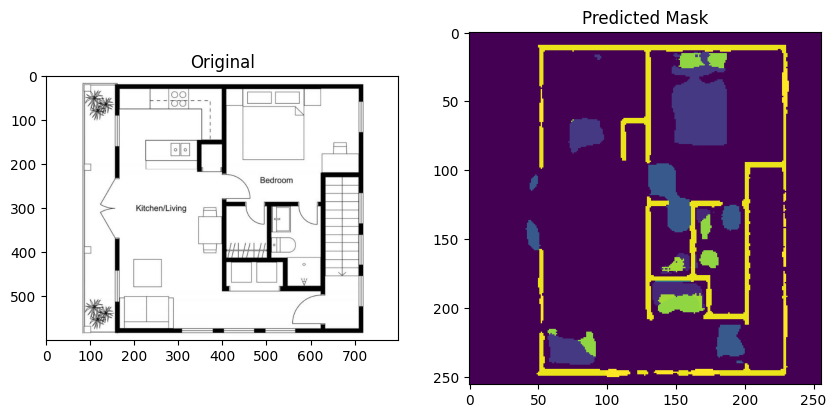

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(pred)
plt.title("Predicted Mask")

plt.show()

### Overlay

(np.float64(-0.5), np.float64(799.5), np.float64(599.5), np.float64(-0.5))

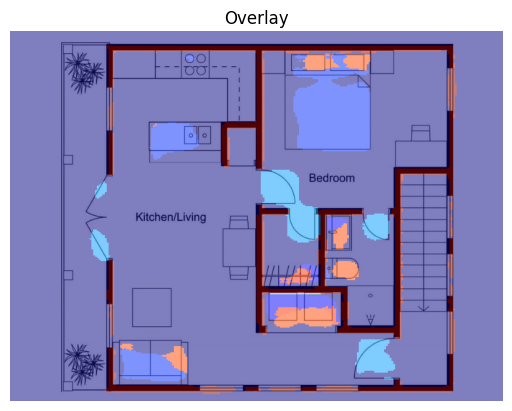

In [68]:
def overlay(image, mask, alpha=0.5):
    mask_colored = plt.cm.jet(mask / mask.max())[:, :, :3]
    overlay = (1 - alpha) * image/255 + alpha * mask_colored
    return overlay


pred_resized = cv2.resize(pred, (image.shape[1], image.shape[0]), interpolation=cv2.INTER_NEAREST)

plt.imshow(overlay(image, pred_resized))
plt.title("Overlay")
plt.axis("off")